In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm.auto import tqdm

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 360
matplotlib.rcParams['text.usetex'] = True
matplotlib.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
# plt.style.use('dark_background')
import seaborn as sns

from sbi.inference import NPE
from sbi.analysis import pairplot
from sbi.utils import BoxUniform
from sbi.neural_nets import posterior_nn

import torch
torch.manual_seed(42)

In [2]:
base = Path('/pscratch/sd/v/vtorresg/quijotes/PowerSpectrum/FoF/latin_hypercube')

In [3]:
filename = ('group_003_pk_halo_all_real_los2_CIC_N512_dk2kf_kmax0p5_mono.npz')

In [4]:
params_file = Path('/global/homes/v/vtorresg/quijotes-sbi/latin_hypercube_params.txt')

In [7]:
n_cubes = 800
kmin, kmax = 0.01, 0.5

In [8]:
pk_rows = []
k_ref = None

for cube_id in range(n_cubes):
    path = base / str(cube_id) / filename

    with np.load(path, allow_pickle=False) as data:
        k = np.asarray(data['k_center'], dtype=float).reshape(-1)
        pk = np.asarray(data['Pk0'], dtype=float).reshape(-1)

    if k_ref is None:
        k_ref = k.copy()
    elif (k.shape != k_ref.shape or not np.allclose(k, k_ref, rtol=1e-6, atol=1e-10)):
        raise ValueError()

    pk_rows.append(pk)

In [84]:
Pk_all = np.stack(pk_rows)
Pk_all.shape

(600, 40)

In [85]:
mask = (k_ref >= kmin) & (k_ref <= kmax)
k_use = k_ref[mask]

Pk_use = Pk_all[:, mask]
if np.any(Pk_use <= 0):
    raise ValueError()

In [86]:
x = torch.from_numpy(np.log10(Pk_use).astype(np.float32))

In [87]:
params = np.loadtxt(params_file)
theta = torch.from_numpy(params.astype(np.float32))

In [88]:
rng = np.random.default_rng(42)
indices = rng.permutation(n_cubes)
train_ids = indices[:450]
test_ids = indices[450:]

In [89]:
x_train, x_test = x[train_ids], x[test_ids]
theta_train, theta_test = theta[train_ids], theta[test_ids]

print('pks:', Pk_all.shape)
print('input:', x.shape)
print('params:', theta.shape)
print('centers:', k_use.min(), '-', k_use.max())

pks: (600, 40)
input: torch.Size([600, 39])
params: torch.Size([2000, 5])
centers: 0.01884955592153876 - 0.49637163926718736


In [90]:
prior = BoxUniform(low=torch.tensor([0.1, 0.03, 0.5, 0.8, 0.6], dtype=torch.float32),
                                    high = torch.tensor([0.5, 0.07, 0.9, 1.2, 1.0], dtype=torch.float32))

In [91]:
print(theta_train.shape)
print(x_train.shape)

print(torch.isfinite(x_train).all())
print(torch.isfinite(theta_train).all())

torch.Size([450, 5])
torch.Size([450, 39])
tensor(True)
tensor(True)


In [92]:
builder = posterior_nn(model='nsf',
                       hidden_features=128, #128 > 256 > 64 > 32
                       num_transforms=5,
                       z_score_x='independent',
                       z_score_theta='independent')

In [93]:
inference = NPE(prior=prior, density_estimator=builder,)

In [94]:
# density_estimator = (inference.append_simulations(theta_train, x_train).train())
density_estimator = inference.append_simulations(theta_train, x_train,).train(training_batch_size=128,
                                                                              learning_rate=5e-4,
                                                                              validation_fraction=0.1,
                                                                              stop_after_epochs=30,
                                                                              max_num_epochs=1000,
                                                                              show_train_summary=True)

 Neural network successfully converged after 257 epochs.
        -------------------------
        ||||| ROUND 1 STATS |||||:
        -------------------------
        Epochs trained: 257
        Best validation performance: -11.8981
        -------------------------
        


In [95]:
# samples = posterior.sample((50000,), x=x_obs)
posterior = inference.build_posterior(density_estimator)

In [96]:
n_test = len(x_test)
truth = theta_test.cpu().numpy()

In [97]:
means = np.zeros(truth.shape, dtype=np.float64)
stds = np.zeros_like(means)

In [98]:
low68 = np.zeros_like(means)
high68 = np.zeros_like(means)
low95 = np.zeros_like(means)
high95 = np.zeros_like(means)

In [99]:
names = ['Omega_m', 'Omega_b', 'h', 'n_s', 'sigma8']
names_l = [r'$\Omega_m$', r'$\Omega_b$', r'$h$', r'$n_s$', r'$\sigma_8$']

In [100]:
n_test = len(x_test)
n_samples = 5000

In [101]:
truth = torch.as_tensor(theta_test).detach().cpu().numpy()

In [102]:
means = np.zeros_like(truth)
stds = np.zeros_like(truth)
low68 = np.zeros_like(truth)
high68 = np.zeros_like(truth)
low95 = np.zeros_like(truth)
high95 = np.zeros_like(truth)

In [103]:
for j in tqdm(range(n_test), desc='Eval cube'):
    samples_j = posterior.sample((n_samples,), x=x_test[j], show_progress_bars=False).detach().cpu().numpy()

    means[j] = samples_j.mean(axis=0)
    stds[j] = samples_j.std(axis=0, ddof=1)

    quantiles = np.quantile(samples_j, [0.025, 0.16, 0.84, 0.975], axis=0,)
    low95[j], low68[j], high68[j], high95[j] = quantiles

Eval cube:   0%|          | 0/150 [00:00<?, ?it/s]

In [104]:
errors = means - truth

In [105]:
inside68 = (truth >= low68) & (truth <= high68)
inside95 = (truth >= low95) & (truth <= high95)

In [106]:
summary = pd.DataFrame({'param': names,
                        'bias': errors.mean(axis=0),
                        'RMSE': np.sqrt((errors**2).mean(axis=0)),
                        'mean_posterior_std': stds.mean(axis=0),
                        'mean_68_interval_width': (high68 - low68).mean(axis=0),
                        'coverage_68': inside68.mean(axis=0),
                        'coverage_95': inside95.mean(axis=0)})
print(summary.to_string(index=False, float_format=lambda v: f'{v:.4f}'))

  param    bias   RMSE  mean_posterior_std  mean_68_interval_width  coverage_68  coverage_95
Omega_m -0.0043 0.0536              0.0411                  0.0851       0.5867       0.9000
Omega_b -0.0013 0.0109              0.0109                  0.0246       0.7000       0.9600
      h -0.0179 0.1118              0.1053                  0.2282       0.6333       0.9067
    n_s  0.0142 0.1007              0.0911                  0.1993       0.5667       0.9600
 sigma8 -0.0065 0.0408              0.0345                  0.0731       0.5867       0.9133


In [107]:
for i, name in enumerate(names):
    print(f'{name:8s} '
          f'true={truth[0, i]:.4f} '
          f'posterior={means[0, i]:.4f} ± {stds[0, i]:.4f}')

Omega_m  true=0.2119 posterior=0.2603 ± 0.0484
Omega_b  true=0.0470 posterior=0.0489 ± 0.0113
h        true=0.8385 posterior=0.6670 ± 0.1092
n_s      true=0.9815 posterior=0.9675 ± 0.1065
sigma8   true=0.6585 posterior=0.6792 ± 0.0302


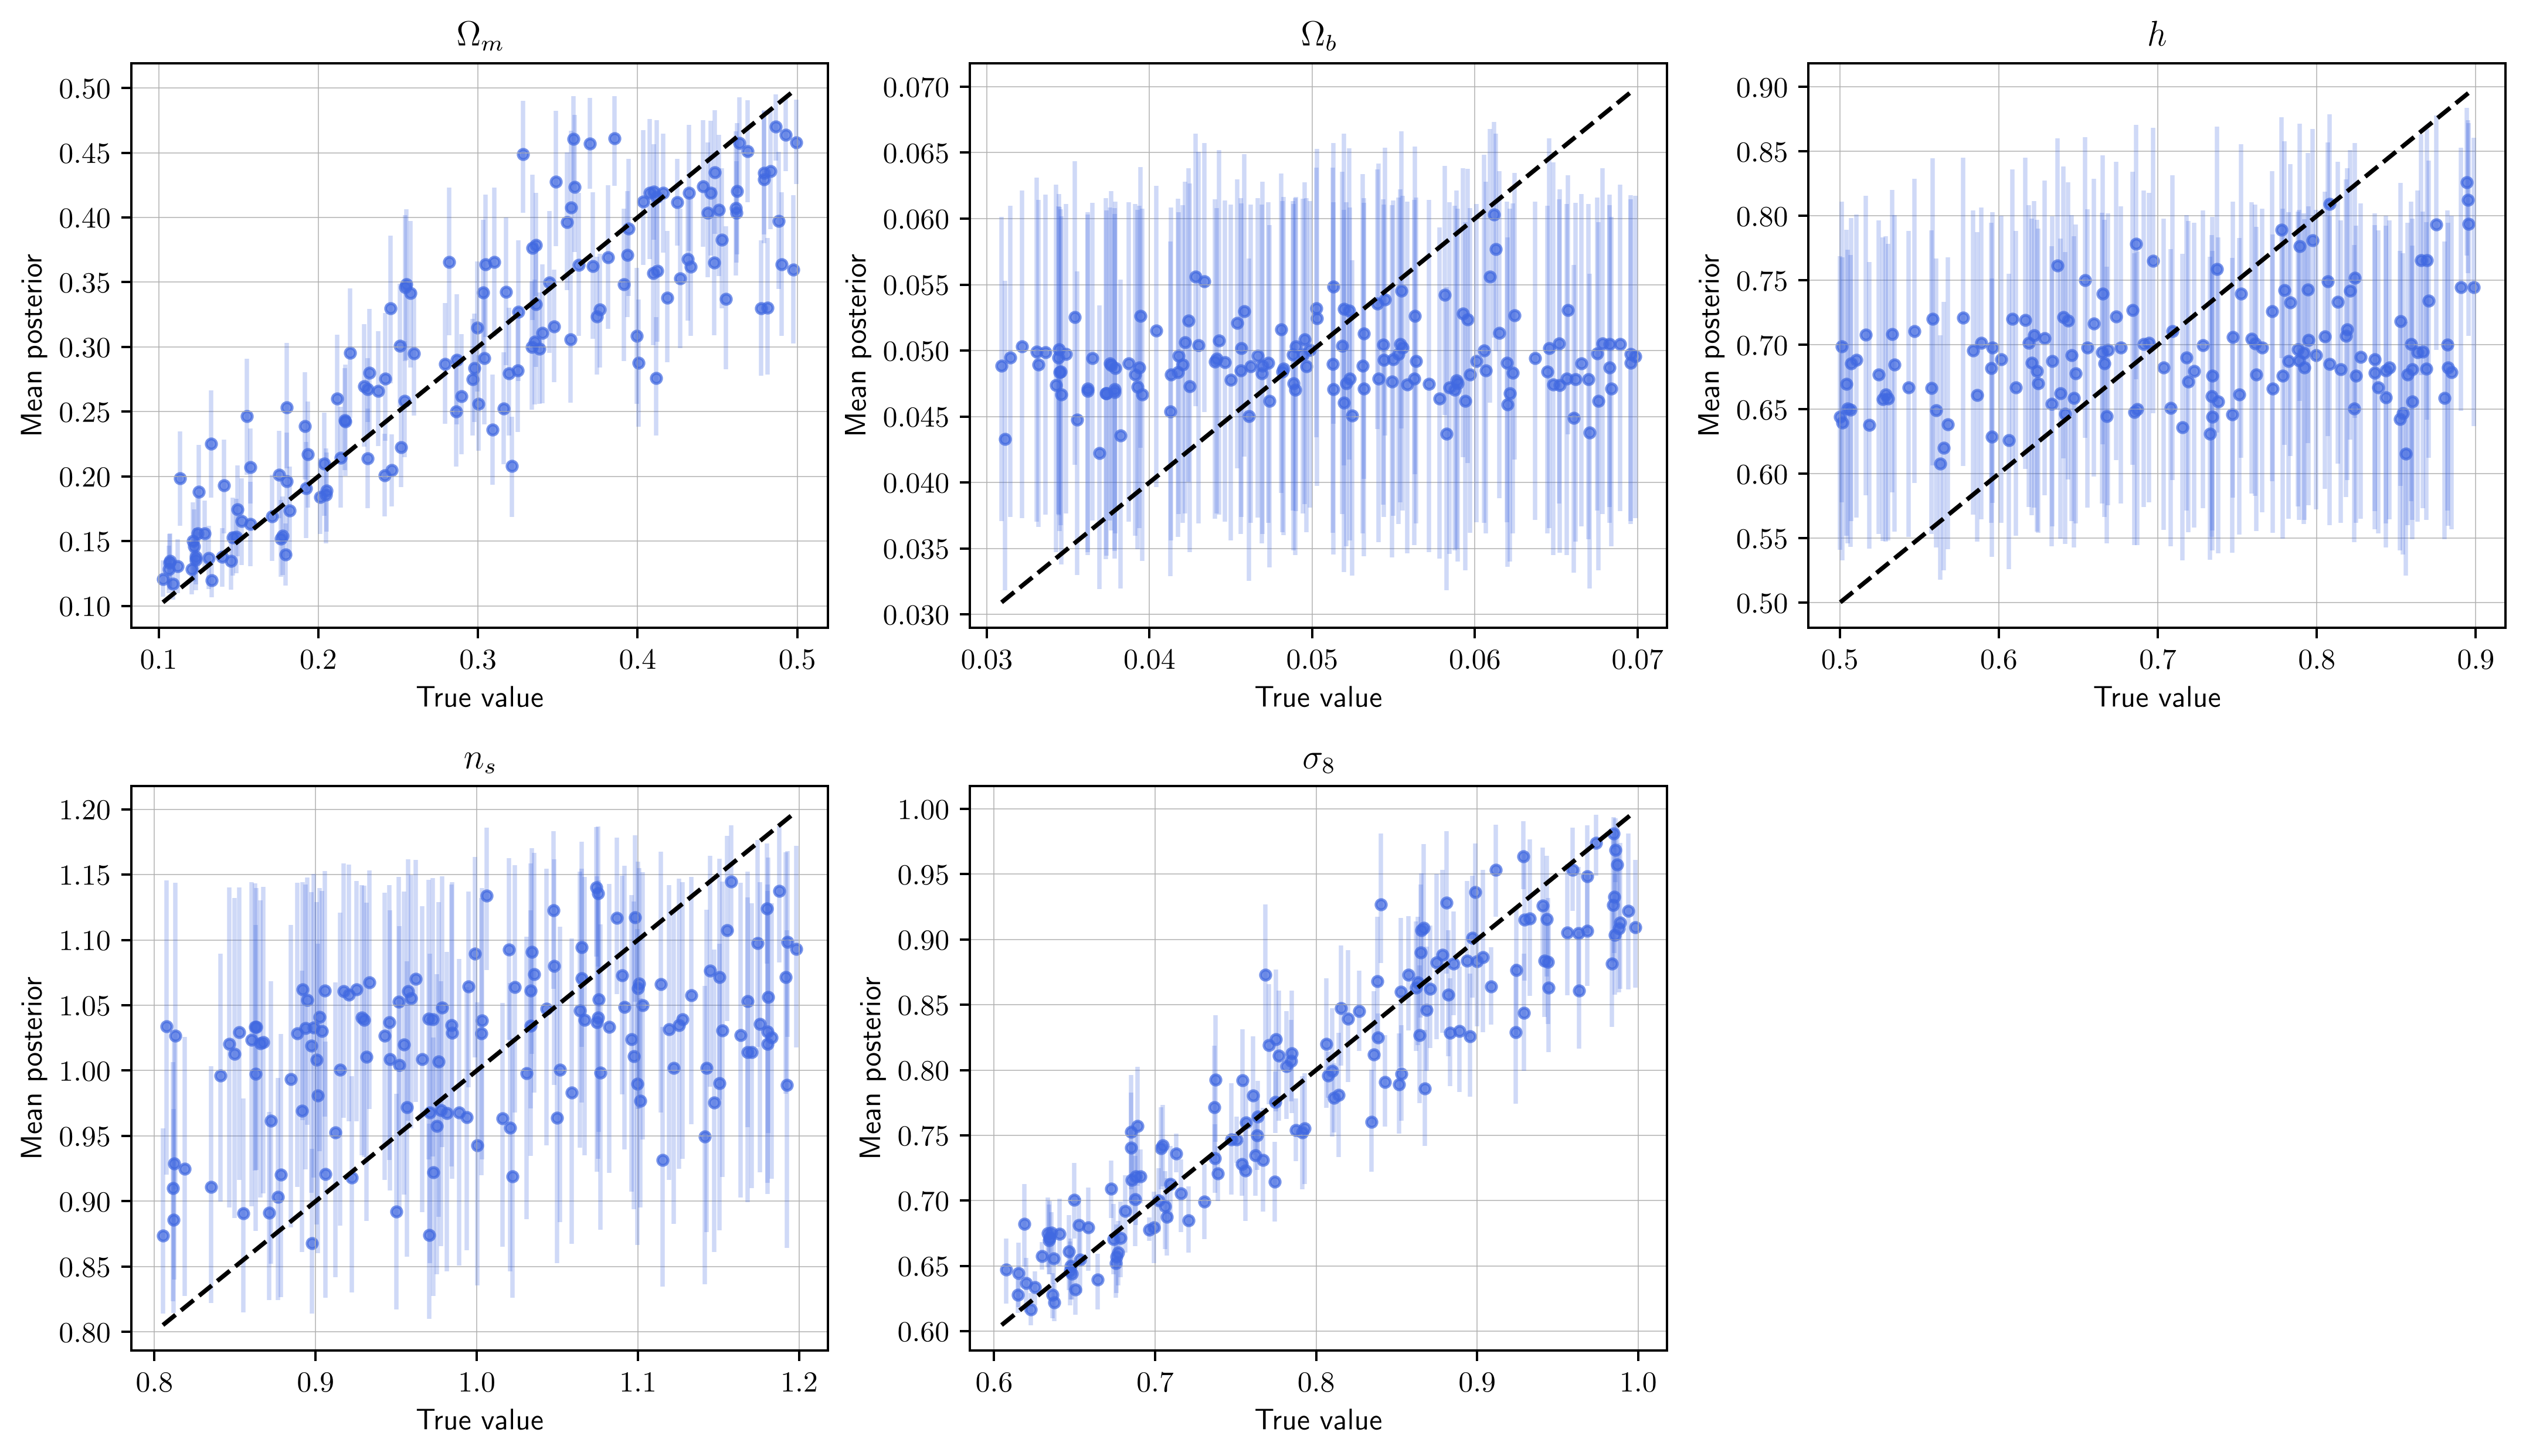

In [108]:
fig, axes = plt.subplots(2, 3, figsize=(12, 7), )
axes = axes.ravel()

for i, name in enumerate(names_l):
    ax = axes[i]
    
    ax.vlines(truth[:, i], low68[:, i], high68[:, i], color='royalblue', alpha=0.25)
    ax.scatter(truth[:, i], means[:, i], s=12, color='royalblue', alpha=0.7)

    limits = [min(truth[:, i].min(), low68[:, i].min(), means[:, i].min()),
              max(truth[:, i].max(), high68[:, i].max(), means[:, i].max())]
    ax.plot(limits, limits, '--', color='black')
    ax.set_xlabel('True value')
    ax.set_ylabel('Mean posterior')
    ax.set_title(names_l[i])
    ax.grid(lw=0.3)

fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

In [109]:
positions = np.arange(len(names))

<>:4: SyntaxWarning: invalid escape sequence '\%'
<>:5: SyntaxWarning: invalid escape sequence '\%'
<>:4: SyntaxWarning: invalid escape sequence '\%'
<>:5: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_2112981/3346508066.py:4: SyntaxWarning: invalid escape sequence '\%'
  ax.bar(positions - 0.18, summary['coverage_68'], width=0.36, label='68\% interval', color='royalblue')
/tmp/ipykernel_2112981/3346508066.py:5: SyntaxWarning: invalid escape sequence '\%'
  ax.bar(positions + 0.18, summary['coverage_95'], width=0.36, label='95\% interval', color='darkorange')


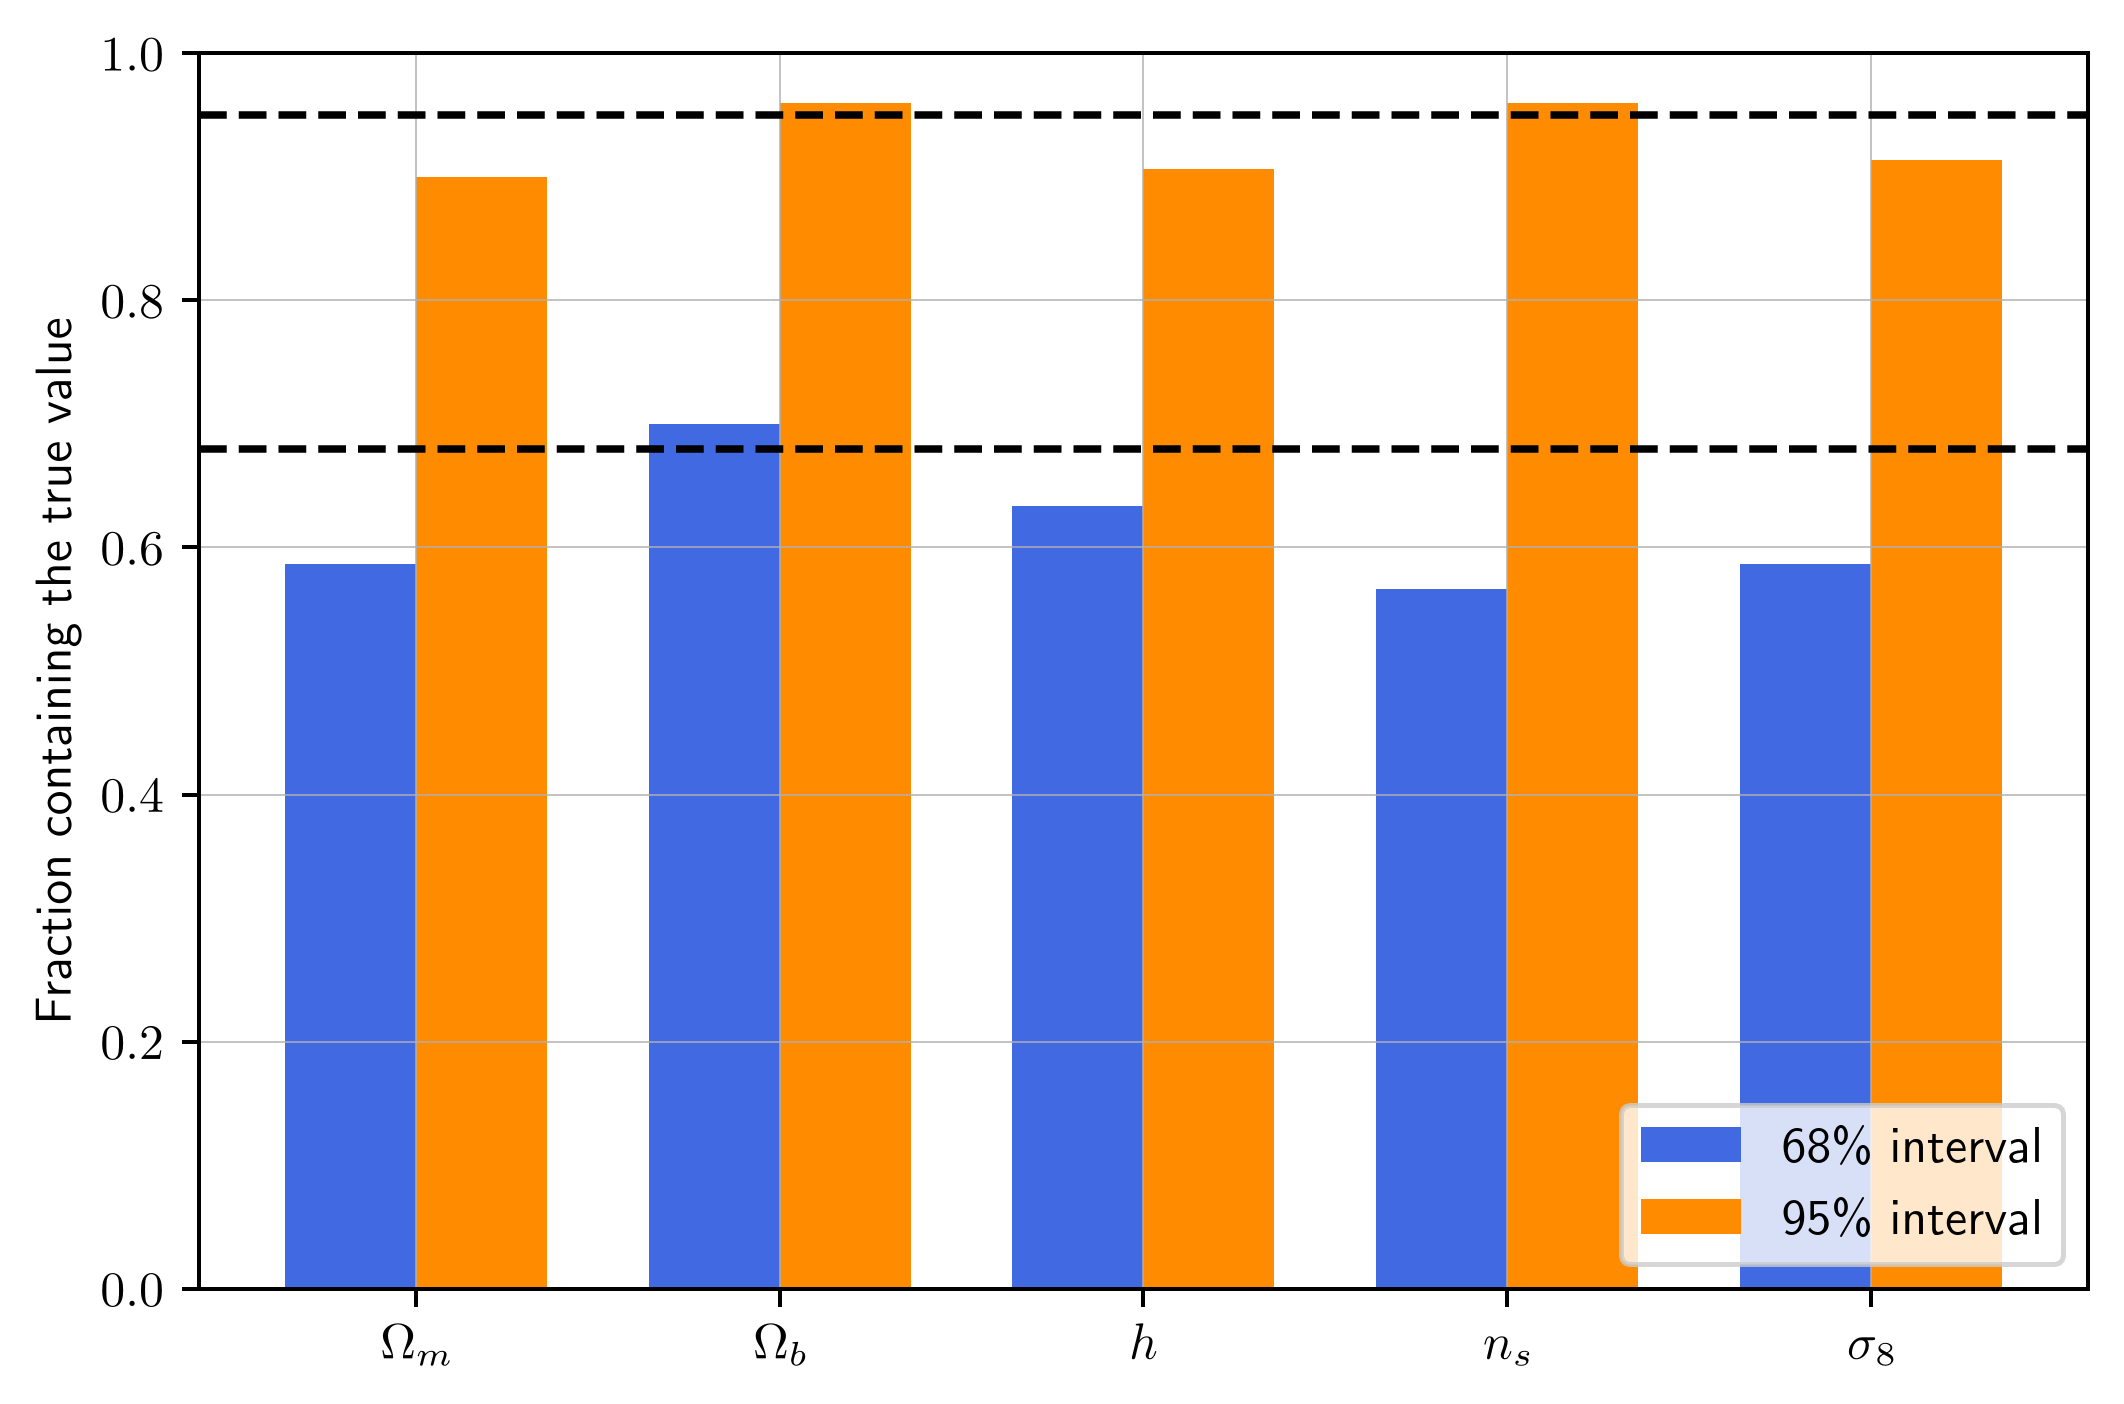

In [110]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.grid(lw=0.3)

ax.bar(positions - 0.18, summary['coverage_68'], width=0.36, label='68\% interval', color='royalblue')
ax.bar(positions + 0.18, summary['coverage_95'], width=0.36, label='95\% interval', color='darkorange')

ax.axhline(0.68, color='black', linestyle='--')
ax.axhline(0.95, color='black', linestyle='--')

ax.set_xticks(positions)
ax.set_xticklabels(names_l)
ax.set_ylabel('Fraction containing the true value')
ax.set_ylim(0, 1)
ax.legend(loc='lower right')

plt.tight_layout()
plt.show()

In [120]:
idx = 0
samples = posterior.sample((50_000,), x=x_test[idx], show_progress_bars=False).detach().cpu().numpy()

In [121]:
true_values = theta_test[idx].detach().cpu().numpy()
posterior_means = samples.mean(axis=0)

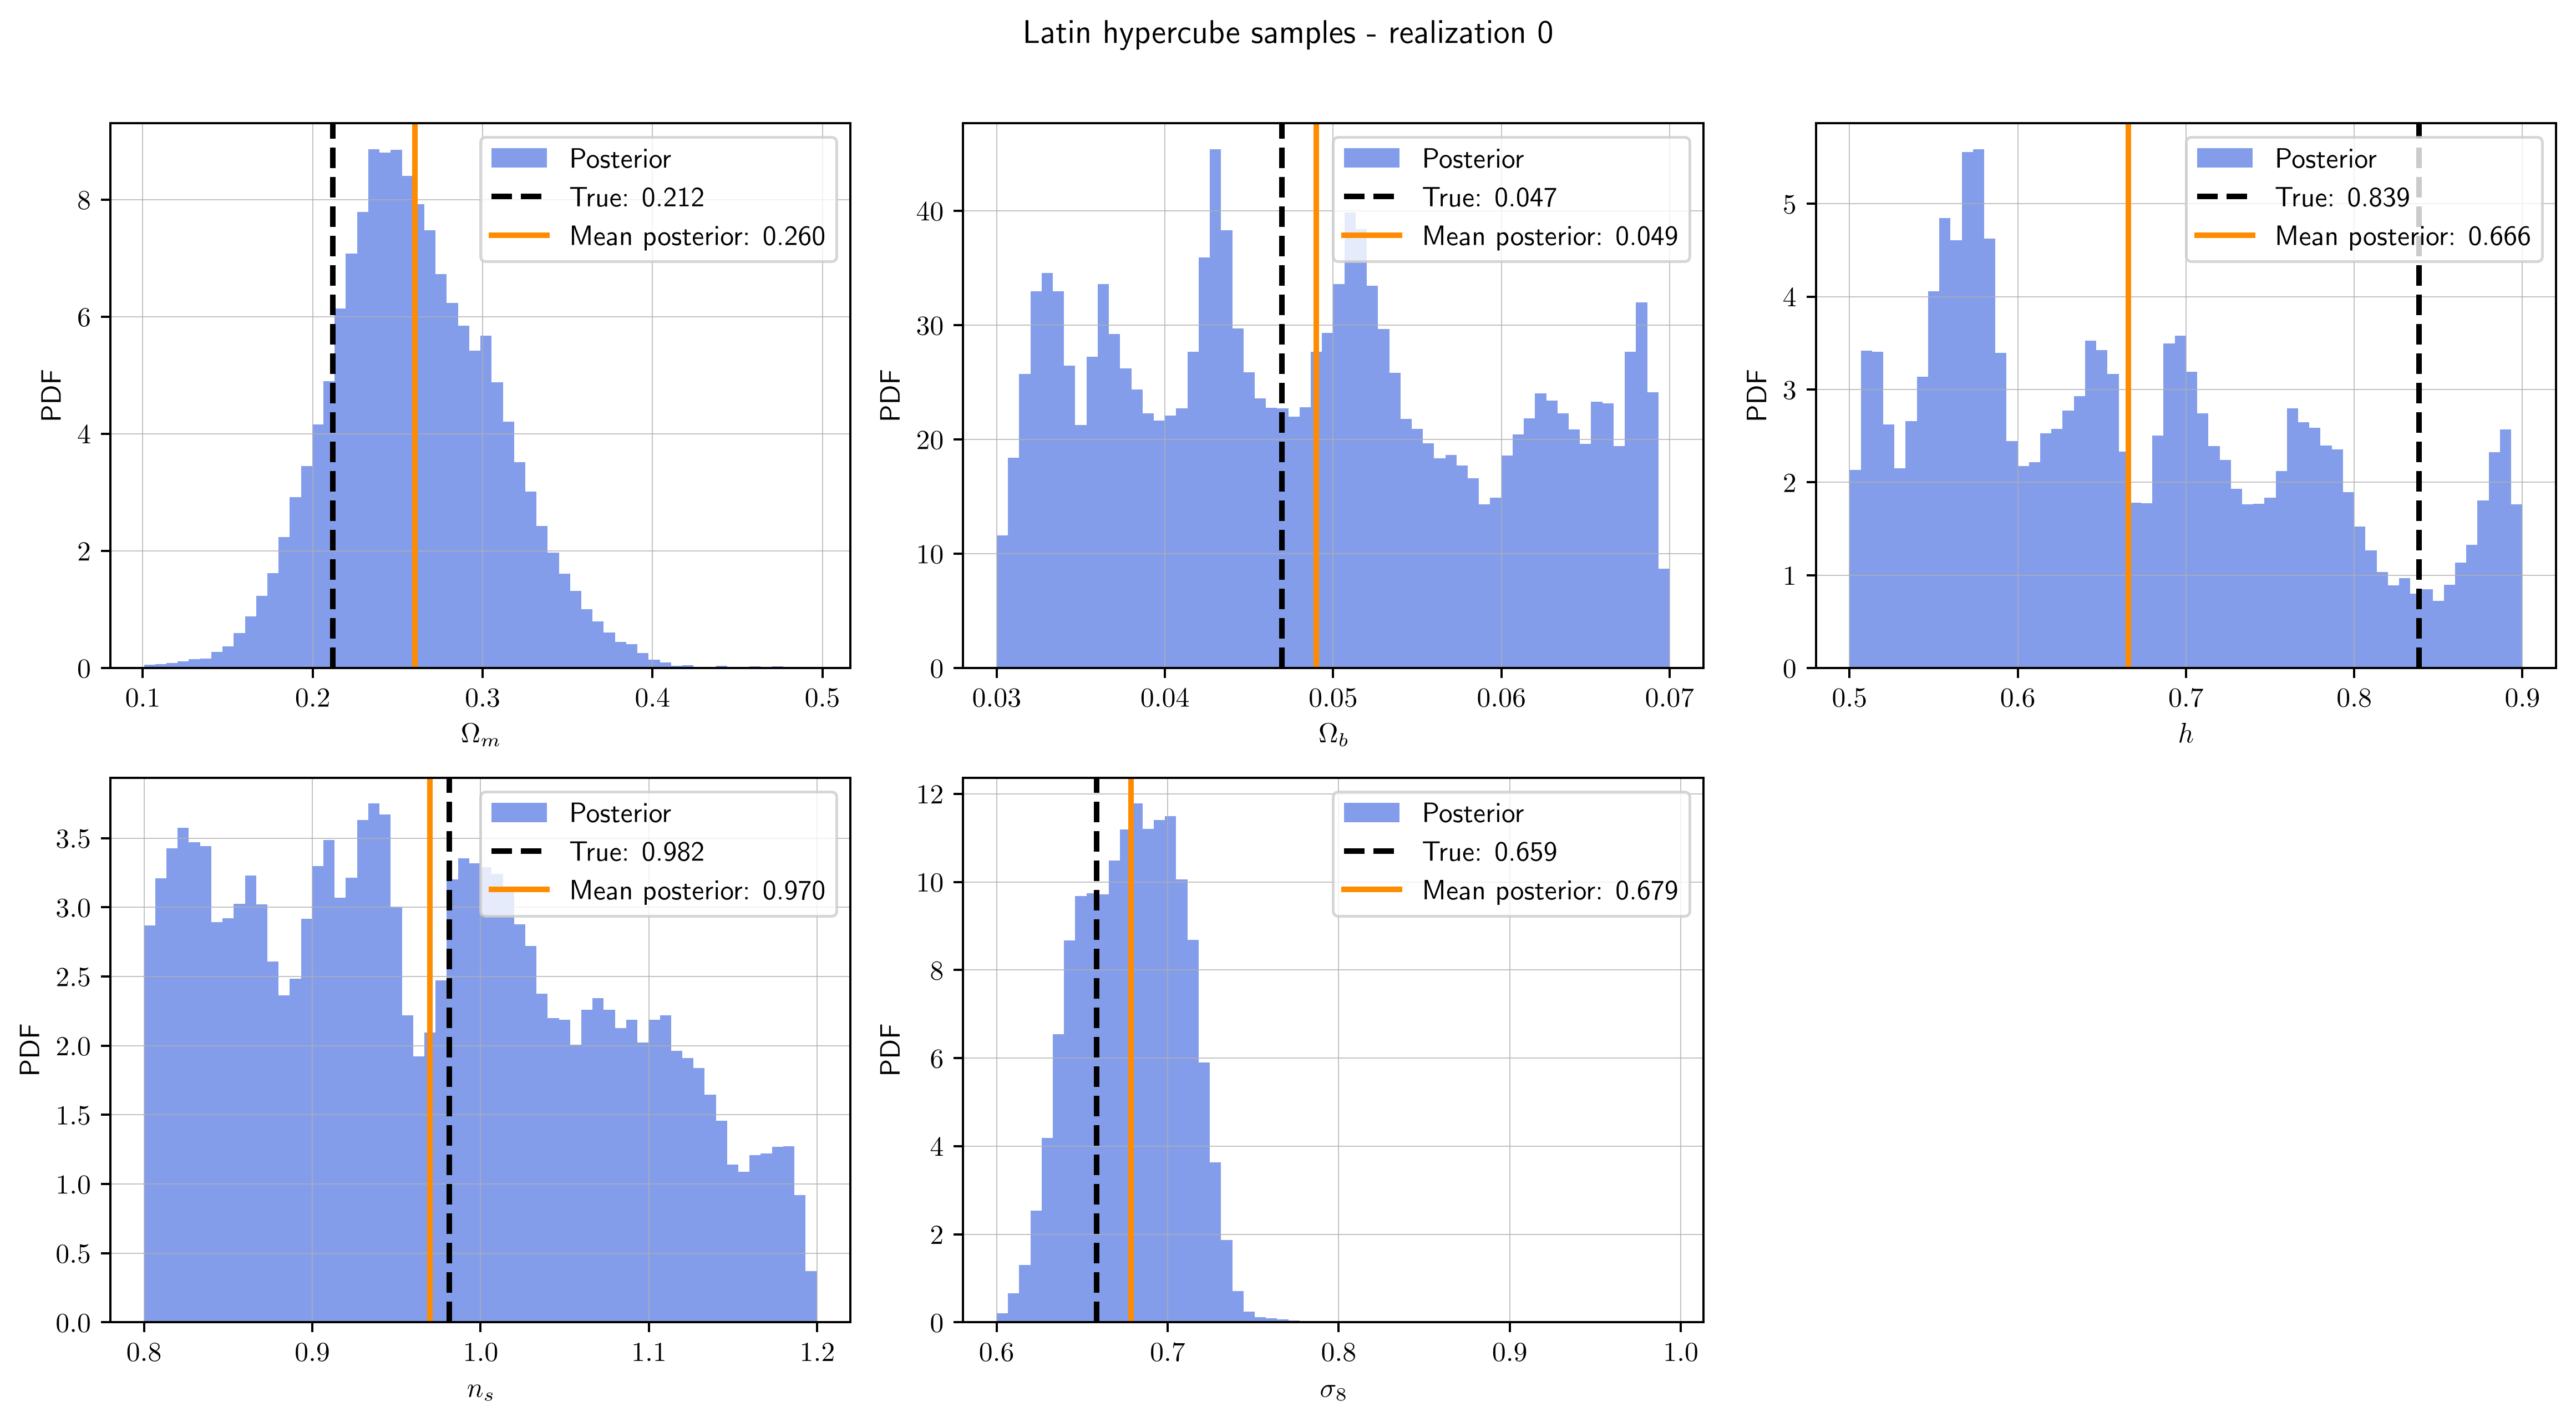

In [122]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
axes = axes.ravel()

for j, label in enumerate(names_l):
    ax = axes[j]

    ax.hist(samples[:, j], bins=60, density=True, color='royalblue', alpha=0.65, label='Posterior')

    ax.axvline(true_values[j], color='black', linewidth=2, linestyle='--', label=f'True: {true_values[j]:.3f}')
    ax.axvline(posterior_means[j], color='darkorange', linewidth=2, label=f'Mean posterior: {posterior_means[j]:.3f}')

    ax.set_xlabel(label)
    ax.set_ylabel('PDF')
    ax.legend()
    ax.grid(lw=0.3)

fig.delaxes(axes[-1])
fig.suptitle(f'Latin hypercube samples - realization {idx}', y=1.01)
plt.tight_layout()
plt.show()